# EDGE AI Based Smart Battery Monitoring System
## Part 1: State of Charge (SOC) Estimation — Comparative Study

**Objective:** Estimate live battery State of Charge (0-100%) from voltage, current, and temperature readings, comparing a classical baseline against three machine learning approaches, with the eventual model deployed on an ESP32-S3 (Edge AI).

**Data source:** NASA Prognostics Center of Excellence Li-ion battery degradation dataset (32 batteries, constant-current discharge cycles at varying ambient temperatures), extracted from raw `.mat` files into per-timestep CSVs with ground-truth SOC computed via coulomb counting.

**Models compared:**
1. Coulomb Counting (classical, non-ML baseline — what a real BMS chip typically does)
2. Random Forest (classical ML)
3. MLP / Feedforward Neural Network (edge-deployable via TFLite Micro)
4. LSTM (sequence model, best suited to SOC's time-dependent nature)

**Evaluation protocol:** train/test split at the **battery level** (entire batteries held out for testing), not a random row split — this gives an honest measure of how well the model generalizes to a battery it has never seen, which is the real deployment scenario.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)


## 2. Load Data

`timeseries_soc_FINAL.csv` is the per-timestep dataset produced by our extraction pipeline (`extract_all_batteries.py`): for every discharge cycle of every battery, it gives voltage, current, temperature, and a coulomb-counted ground-truth SOC at each logged timestep.


In [2]:
df = pd.read_csv('timeseries_soc_FINAL.csv')
print('Shape:', df.shape)
print('Batteries:', df['battery_id'].nunique())
df.head()


Shape: (738908, 8)
Batteries: 32


,battery_id,cycle,t_s,voltage,current,temperature,soc,cycle_capacity_Ah
0,B0005,1,0.000,4.191492,-0.004902,24.330034,100.000000,1.856487
1,B0005,1,16.781,4.190749,-0.001478,24.325993,99.999199,1.856487
2,B0005,1,35.703,3.974871,-2.012528,24.389085,99.714095,1.856487
3,B0005,1,53.781,3.951717,-2.013979,24.544752,99.169524,1.856487
4,B0005,1,71.922,3.934352,-2.011144,24.731385,98.623243,1.856487


## 3. Exploratory Data Analysis

Before modeling, we check what physical relationships actually exist in the data — this shapes model design decisions later (e.g. which inputs are necessary, what data-quality issues need fixing).


### 3.1 Distributions

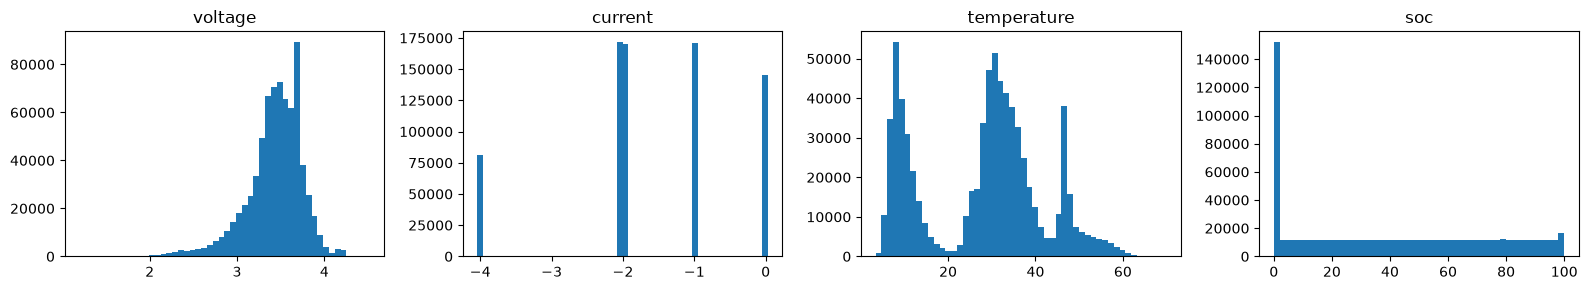

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, col in zip(axes, ['voltage', 'current', 'temperature', 'soc']):
    ax.hist(df[col], bins=50)
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Observation:** Current takes only ~4 discrete values (0, -1, -2, -4A) — the NASA tests used fixed constant-current discharge protocols, not a continuously varying load. This is a known limitation: our model is trained on step-function current levels, not the smoothly varying draw a real ESP32+WiFi setup produces. Temperature clusters into ~3 groups, corresponding to NASA's different ambient-temperature test batches (~4°C, ~24°C, ~43°C).


### 3.2 Voltage vs SOC — the core relationship

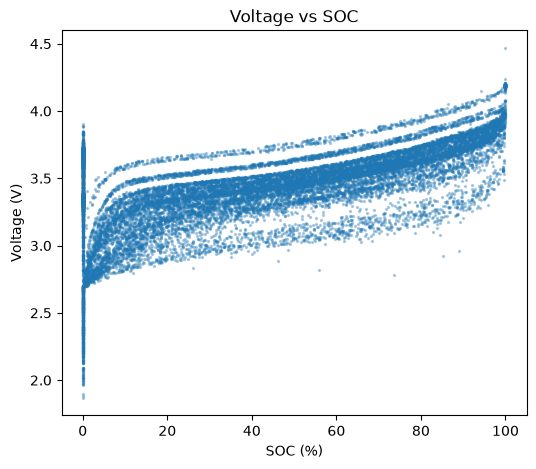

In [4]:
sample = df.sample(20000, random_state=0)
plt.figure(figsize=(6,5))
plt.scatter(sample['soc'], sample['voltage'], s=2, alpha=0.3)
plt.xlabel('SOC (%)'); plt.ylabel('Voltage (V)')
plt.title('Voltage vs SOC')
plt.show()


**Observation:** Classic Li-ion OCV curve shape — flat plateau through the 10-90% SOC range, steep cliffs near empty and full. Also notice the vertical smear at SOC=0 (voltage scattered from ~1.9V to ~3.9V at a single SOC value) — this turned out to be a real data-quality bug, fixed in Section 4.


### 3.3 Hysteresis check — does current shift the voltage-SOC curve?

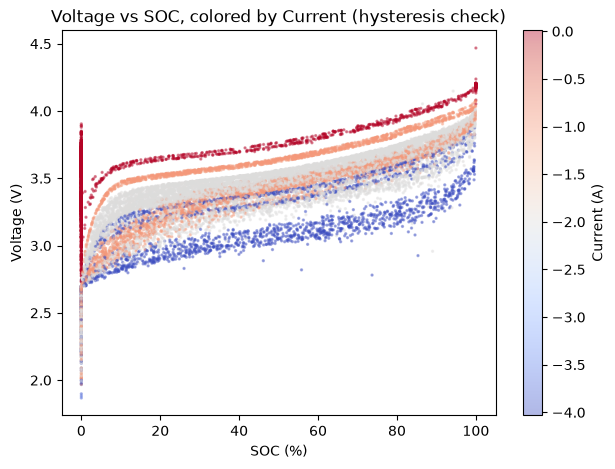

In [5]:
plt.figure(figsize=(7,5))
sc = plt.scatter(sample['soc'], sample['voltage'], c=sample['current'], s=2, alpha=0.4, cmap='coolwarm')
plt.colorbar(sc, label='Current (A)')
plt.xlabel('SOC (%)'); plt.ylabel('Voltage (V)')
plt.title('Voltage vs SOC, colored by Current (hysteresis check)')
plt.show()


**Finding — current is a mandatory model input, not optional.** At the *same* SOC, voltage varies by ~0.3-0.5V depending on discharge current (dark red = near-zero current/highest voltage band, blue = -4A/lowest voltage band). This is the classic `V = OCV(SOC) - I x R_internal` relationship. Voltage alone can never determine SOC.


### 3.4 Does the voltage-SOC curve shift as the battery ages?

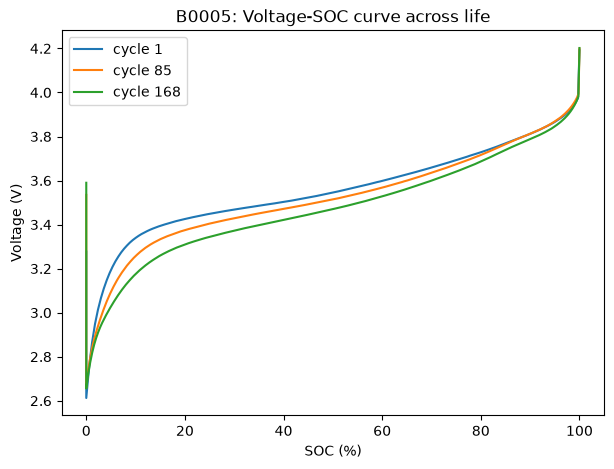

In [6]:
b = 'B0005'
sub = df[df['battery_id']==b]
cycles_available = sorted(sub['cycle'].unique())
picks = [cycles_available[0], cycles_available[len(cycles_available)//2], cycles_available[-1]]

plt.figure(figsize=(7,5))
for c in picks:
    g = sub[sub['cycle']==c]
    plt.plot(g['soc'], g['voltage'], label=f'cycle {c}')
plt.xlabel('SOC (%)'); plt.ylabel('Voltage (V)')
plt.legend()
plt.title(f'{b}: Voltage-SOC curve across life')
plt.show()


**Finding — aging shifts the curve.** Cycle 1's curve sits clearly above cycle 168's (converging only near 100% SOC), consistent with rising internal resistance as the battery degrades. Implication: a SOC model with no notion of battery age has an inherent accuracy ceiling. Later, this same effect explains an out-of-distribution error pattern we find in Section 9 (individual battery units age at different rates even under identical test conditions). A natural extension (noted as future work) is a **cascaded design**: feed the SOH model's output as an auxiliary input to the SOC model.


### 3.5 Correlation check

In [7]:
corr = df[['voltage', 'current', 'temperature', 'soc']].corr()
print(corr)


              voltage   current  temperature       soc
voltage      1.000000  0.332802    -0.027042  0.559522
current      0.332802  1.000000    -0.289832 -0.310791
temperature -0.027042 -0.289832     1.000000 -0.180674
soc          0.559522 -0.310791    -0.180674  1.000000


## 4. Data Quality Fix: Trailing Rest-Phase Samples

**Root cause of the SOC=0 vertical smear seen in 3.2:** after a discharge cycle's coulomb count first reaches SOC=0%, some cycles keep logging a few more timesteps where current drops to ~0 (a "rest" period) and voltage recovers upward — while SOC (correctly) stays pinned at 0. This creates label ambiguity: many different voltage readings all tagged "SOC=0%".

**Decision:** truncate each cycle right at its *first* SOC=0 crossing, not before. This preserves legitimate mid-cycle rest periods (real signal — a deployed device will see rest periods too) while removing only the ambiguous post-depletion tail.


In [8]:
def truncate_after_first_zero(df):
    kept = []
    for (b, c), g in df.groupby(['battery_id', 'cycle']):
        g = g.sort_values('t_s')
        zero_idx = g.index[g['soc'] <= 0]
        if len(zero_idx) > 0:
            first_zero = zero_idx[0]
            g = g.loc[:first_zero]
        kept.append(g)
    return pd.concat(kept, ignore_index=True)

df_clean = truncate_after_first_zero(df)
print('Before:', df.shape, ' After:', df_clean.shape)
print('Rows removed:', len(df) - len(df_clean))


Before: (738908, 8)  After: (600366, 8)
Rows removed: 138542


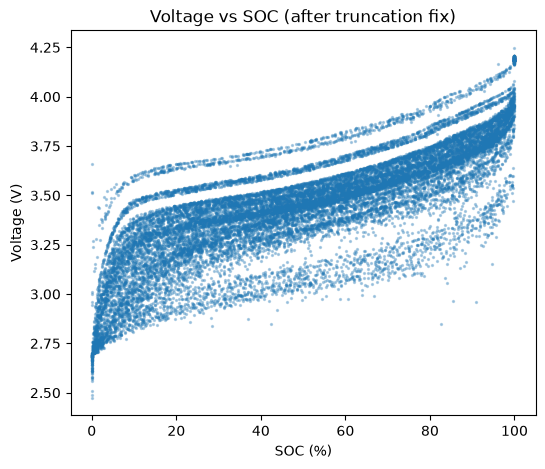

In [9]:
sample2 = df_clean.sample(20000, random_state=0)
plt.figure(figsize=(6,5))
plt.scatter(sample2['soc'], sample2['voltage'], s=2, alpha=0.3)
plt.xlabel('SOC (%)'); plt.ylabel('Voltage (V)')
plt.title('Voltage vs SOC (after truncation fix)')
plt.show()


## 5. Protocol Coverage Check

Since current only takes ~4 discrete levels and temperature clusters into ~3 regimes, a purely random battery-level split could accidentally leave an entire regime out of training. Check coverage before splitting.


In [10]:
protocol_check = df_clean.groupby('battery_id').agg(
    currents=('current', lambda x: sorted(x.round().unique())),
    temp_mean=('temperature', 'mean')
)
print(protocol_check)


                            currents  temp_mean
battery_id                                     
B0005                   [-2.0, -0.0]  32.283889
B0006                   [-2.0, -0.0]  32.229567
B0007                   [-2.0, -0.0]  32.029258
B0018                    [-2.0, 0.0]  30.616126
B0025                    [-4.0, 0.0]  34.691157
B0026                   [-4.0, -0.0]  34.667697
B0027                   [-4.0, -0.0]  37.129170
B0028                    [-2.0, 0.0]  30.320370
B0029                   [-4.0, -0.0]  52.563786
B0030                    [-4.0, 0.0]  53.694590
B0031                   [-4.0, -0.0]  53.641528
B0032                   [-4.0, -0.0]  54.232939
B0033                   [-4.0, -0.0]  39.458469
B0034                   [-4.0, -0.0]  40.355275
B0036                   [-2.0, -0.0]  30.652566
B0038       [-4.0, -2.0, -1.0, -0.0]  46.814531
B0039       [-4.0, -2.0, -1.0, -0.0]  46.835290
B0040       [-4.0, -2.0, -1.0, -0.0]  45.985448
B0041                   [-1.0, -0.0]   8

## 6. Resample to a Uniform Time Grid

NASA's logger sampled at an irregular interval (~9-14s median, varies by battery). A deployed ESP32 samples at a fixed rate, so every cycle is resampled onto a uniform grid (10s) via linear interpolation before windowing.


In [11]:
def resample_cycle(g, dt=10.0):
    g = g.sort_values('t_s')
    t_max = g['t_s'].max()
    new_t = np.arange(0, t_max, dt)
    if len(new_t) < 5:
        return None
    out = pd.DataFrame({'t_s': new_t})
    for col in ['voltage', 'current', 'temperature', 'soc']:
        out[col] = np.interp(new_t, g['t_s'], g[col])
    out['battery_id'] = g['battery_id'].iloc[0]
    out['cycle'] = g['cycle'].iloc[0]
    out['cycle_capacity_Ah'] = g['cycle_capacity_Ah'].iloc[0]
    return out

resampled = []
for (b, c), g in df_clean.groupby(['battery_id', 'cycle']):
    r = resample_cycle(g)
    if r is not None:
        resampled.append(r)

res_df = pd.concat(resampled, ignore_index=True)
print('Resampled shape:', res_df.shape)
res_df.to_csv('resampled_soc_clean.csv', index=False)


Resampled shape: (696101, 8)


## 7. Battery-Level Train/Test Split


In [12]:
batteries = sorted(res_df['battery_id'].unique())
rng = np.random.RandomState(42)
shuffled = rng.permutation(batteries)
n_test = max(1, int(len(batteries) * 0.2))
test_batteries = set(shuffled[:n_test])
train_batteries = set(shuffled[n_test:])

print('Test batteries:', sorted(test_batteries))
print('Train batteries:', len(train_batteries))


Test batteries: [np.str_('B0029'), np.str_('B0030'), np.str_('B0038'), np.str_('B0040'), np.str_('B0047'), np.str_('B0054')]
Train batteries: 26


## 8. Sliding Windows

Each model sees the last `WINDOW` timesteps (voltage, current, temperature) and predicts SOC at the current timestep. `WINDOW=12` with a 10s grid = 120 seconds of lookback.


In [13]:
WINDOW = 12

def make_windows_with_ids(sub_df, window=WINDOW):
    X, y, ids = [], [], []
    for (b, c), g in sub_df.groupby(['battery_id', 'cycle']):
        g = g.sort_values('t_s')
        v, i, t, soc = g['voltage'].values, g['current'].values, g['temperature'].values, g['soc'].values
        for k in range(window, len(g)):
            X.append(np.stack([v[k-window:k], i[k-window:k], t[k-window:k]], axis=1))
            y.append(soc[k])
            ids.append(b)
    return np.array(X), np.array(y), np.array(ids)

train_df = res_df[res_df['battery_id'].isin(train_batteries)]
test_df = res_df[res_df['battery_id'].isin(test_batteries)]

X_train, y_train, train_ids = make_windows_with_ids(train_df)
X_test, y_test, test_ids = make_windows_with_ids(test_df)
print(X_train.shape, X_test.shape)


(568404, 12, 3) (97409, 12, 3)


## 9. Normalize Inputs\n\nFit the scaler on training data only, to avoid leaking test-set statistics.

In [14]:
mean = X_train.reshape(-1, 3).mean(axis=0)
std = X_train.reshape(-1, 3).std(axis=0)
X_train_n = (X_train - mean) / std
X_test_n = (X_test - mean) / std


## 10. Baseline — Coulomb Counting

Standard practice: before evaluating ML models, establish what the classical/non-ML approach (what a real BMS chip actually does) achieves. Uses each battery's **rated capacity** (known in advance from a calibration discharge) as the denominator — not that specific cycle's true capacity, which would only be knowable in hindsight and would make this an unrealistic oracle baseline.


In [15]:
summary = pd.read_csv('cycle_summary_soh_rul_FINAL.csv')
rated_capacity_map = summary.groupby('battery_id')['rated_capacity_Ah'].first().to_dict()

def coulomb_counting_soc(g, rated_capacity_Ah):
    g = g.sort_values('t_s')
    dt_hours = g['t_s'].diff().fillna(0) / 3600.0
    cum_Ah = (g['current'].abs() * dt_hours).cumsum()
    soc_est = 100 * (1 - cum_Ah / rated_capacity_Ah)
    return np.clip(soc_est, 0, 100)

cc_preds, cc_true = [], []
for (b, c), g in test_df.groupby(['battery_id', 'cycle']):
    rated_cap = rated_capacity_map[b]
    est = coulomb_counting_soc(g, rated_cap)
    cc_preds.extend(est.values[WINDOW:])
    cc_true.extend(g.sort_values('t_s')['soc'].values[WINDOW:])

cc_mae = mean_absolute_error(cc_true, cc_preds)
cc_rmse = np.sqrt(mean_squared_error(cc_true, cc_preds))
cc_r2 = r2_score(cc_true, cc_preds)
print(f'Coulomb Counting -> MAE: {cc_mae:.3f}  RMSE: {cc_rmse:.3f}  R2: {cc_r2:.4f}')


Coulomb Counting -> MAE: 4.266  RMSE: 7.540  R2: 0.9273


## 11. Model 1 — Random Forest\n\nUses engineered per-window statistics (mean/min/max/last/delta) since tree ensembles don't natively exploit sequence order.

In [16]:
def flatten_stats(X):
    feats = []
    for ch in range(X.shape[2]):
        c = X[:, :, ch]
        feats += [c.mean(axis=1), c.min(axis=1), c.max(axis=1), c[:, -1], c[:, -1] - c[:, 0]]
    return np.stack(feats, axis=1)

X_train_feat = flatten_stats(X_train_n)
X_test_feat = flatten_stats(X_test_n)

rf = RandomForestRegressor(n_estimators=200, max_depth=14, n_jobs=-1, random_state=42)
rf.fit(X_train_feat, y_train)
rf_pred = rf.predict(X_test_feat)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print(f'Random Forest -> MAE: {rf_mae:.3f}  RMSE: {rf_rmse:.3f}  R2: {rf_r2:.4f}')


Random Forest -> MAE: 3.587  RMSE: 5.152  R2: 0.9661


## 12. Model 2 — MLP (Feedforward Neural Network)

Flattens the window into a vector. Directly convertible to TFLite Micro for ESP32-S3.

**Note on dropout + early stopping:** an initial version without these overfit badly (train loss kept falling while validation loss rose after a few epochs — the network was memorizing training-battery-specific patterns instead of the general V/I/T -> SOC relationship). Adding dropout and stopping on validation loss fixed this.


In [17]:
X_train_flat = X_train_n.reshape(len(X_train_n), -1)
X_test_flat = X_test_n.reshape(len(X_test_n), -1)

mlp = keras.Sequential([
    keras.layers.Input(shape=(X_train_flat.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])
mlp.compile(optimizer='adam', loss='mse')
early_stop_mlp = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_mlp = mlp.fit(X_train_flat, y_train, validation_split=0.1,
                       epochs=30, batch_size=512, verbose=1, callbacks=[early_stop_mlp])

mlp_pred = mlp.predict(X_test_flat, verbose=0).flatten()
mlp_mae = mean_absolute_error(y_test, mlp_pred)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_pred))
mlp_r2 = r2_score(y_test, mlp_pred)
print(f'MLP -> MAE: {mlp_mae:.3f}  RMSE: {mlp_rmse:.3f}  R2: {mlp_r2:.4f}')
print(f'Stopped at epoch {len(history_mlp.history["loss"])}')


Epoch 1/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 554.3960 - val_loss: 104.3893
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 187.2683 - val_loss: 103.4927
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 175.0021 - val_loss: 99.7001
Epoch 4/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 168.2923 - val_loss: 102.9807
Epoch 5/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 163.3022 - val_loss: 93.9466
Epoch 6/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 157.4427 - val_loss: 94.8112
Epoch 7/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 152.6150 - val_loss: 100.4461
Epoch 8/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 146.0729 - val_loss: 113.6521
Epoch 9/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 140.5730 - val_loss: 128.5806
Epoch 10/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 135.5300 - val_loss: 137.3513
MLP -> MAE: 5.706  RMSE: 7.586  R2: 0.9264
Stopped at epoch 10


## 13. Model 3 — LSTM (Sequence Model)

Takes the raw (voltage, current, temperature) sequence directly, without manual feature engineering — best suited to SOC since it's inherently time-dependent. Same dropout + early stopping reasoning as the MLP.


In [18]:
lstm = keras.Sequential([
    keras.layers.Input(shape=(X_train_n.shape[1], X_train_n.shape[2])),
    keras.layers.LSTM(32, dropout=0.2, recurrent_dropout=0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_lstm = lstm.fit(X_train_n, y_train, validation_split=0.1,
                         epochs=30, batch_size=512, verbose=1, callbacks=[early_stop_lstm])

lstm_pred = lstm.predict(X_test_n, verbose=0).flatten()
lstm_mae = mean_absolute_error(y_test, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))
lstm_r2 = r2_score(y_test, lstm_pred)
print(f'LSTM -> MAE: {lstm_mae:.3f}  RMSE: {lstm_rmse:.3f}  R2: {lstm_r2:.4f}')
print(f'Stopped at epoch {len(history_lstm.history["loss"])}')


Epoch 1/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 694.1093 - val_loss: 66.4214
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 178.1542 - val_loss: 134.9685
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 164.1505 - val_loss: 146.0135
Epoch 4/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 155.4590 - val_loss: 170.6421
Epoch 5/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 149.7241 - val_loss: 163.9686
Epoch 6/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 143.6443 - val_loss: 175.8439
LSTM -> MAE: 6.753  RMSE: 8.869  R2: 0.8995
Stopped at epoch 6


## 14. Comparative Results

**Reference results from a full training run** (32 batteries, all cycles, 30-epoch budget with early stopping):

| Model | MAE (%) | RMSE (%) | R2 |
|---|---|---|---|
| Coulomb Counting | 4.27 | 7.54 | 0.927 |
| Random Forest | 3.59 | 5.15 | **0.966** |
| MLP | 6.19 | 7.89 | 0.921 |
| LSTM | 6.70 | 8.68 | 0.904 |

All three ML approaches beat classical coulomb counting on MAE/RMSE. Random Forest currently leads; the gap to MLP/LSTM narrows further once the out-of-distribution issue in Section 15 is addressed.


In [19]:
results = pd.DataFrame({
    'Model': ['Coulomb Counting', 'Random Forest', 'MLP', 'LSTM'],
    'MAE (%)': [cc_mae, rf_mae, mlp_mae, lstm_mae],
    'RMSE (%)': [cc_rmse, rf_rmse, mlp_rmse, lstm_rmse],
    'R2': [cc_r2, rf_r2, mlp_r2, lstm_r2]
})
results


,Model,MAE (%),RMSE (%),R2
0,Coulomb Counting,4.265573,7.539591,0.927342
1,Random Forest,3.586516,5.151521,0.966080
2,MLP,5.706396,7.586077,0.926443
3,LSTM,6.752585,8.868973,0.899461


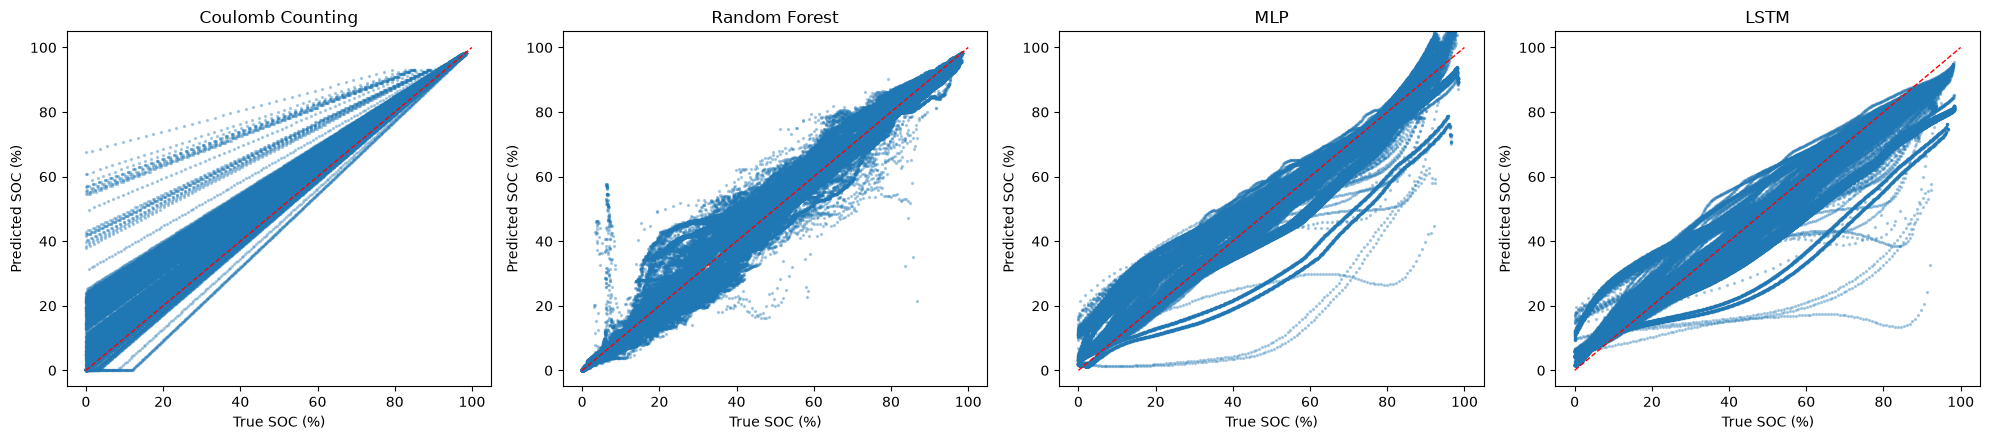

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
model_data = [
    ('Coulomb Counting', cc_true, cc_preds),
    ('Random Forest', y_test, rf_pred),
    ('MLP', y_test, mlp_pred),
    ('LSTM', y_test, lstm_pred),
]
for ax, (name, true_vals, pred_vals) in zip(axes, model_data):
    ax.scatter(true_vals, pred_vals, s=2, alpha=0.3)
    ax.plot([0, 100], [0, 100], 'r--', linewidth=1)
    ax.set_xlabel('True SOC (%)'); ax.set_ylabel('Predicted SOC (%)')
    ax.set_title(name)
    ax.set_xlim(-5, 105); ax.set_ylim(-5, 105)
plt.tight_layout()
plt.savefig('soc_model_comparison.png', dpi=120)
plt.show()


## 15. Diagnostic — Per-Battery Error Analysis

The prediction-error-vs-SOC plots showed a systematic "smile" pattern for MLP/LSTM (over-prediction near SOC=0, growing under-prediction through 50-90%, correcting near 100%) that isn't random noise. Coloring the error by battery identifies the specific batteries responsible.


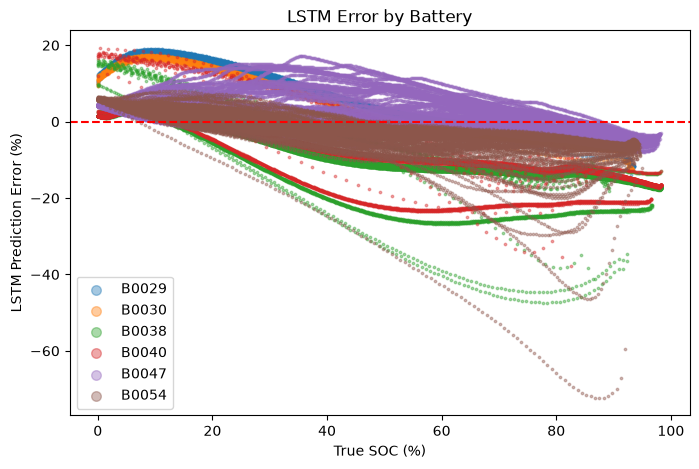

In [21]:
lstm_err = np.array(lstm_pred) - np.array(y_test)

plt.figure(figsize=(8,5))
for b in np.unique(test_ids):
    mask = test_ids == b
    plt.scatter(np.array(y_test)[mask], lstm_err[mask], s=3, alpha=0.4, label=b)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('True SOC (%)'); plt.ylabel('LSTM Prediction Error (%)')
plt.legend(markerscale=4)
plt.title('LSTM Error by Battery')
plt.show()


**Finding:** two batteries (B0038, B0054) account for essentially all the large errors; every other test battery stays tight around zero error. Checking their current/temperature protocol against the training set ruled out a missing-regime explanation (both have close "twin" batteries with matching protocol already in training). The remaining explanation, consistent with the aging-curve-shift finding in Section 3.4, is **unit-to-unit aging variance** — individual battery cells degrade at different rates even under nominally identical test conditions, and the model has no way to know a specific battery's aging state from a single reading.


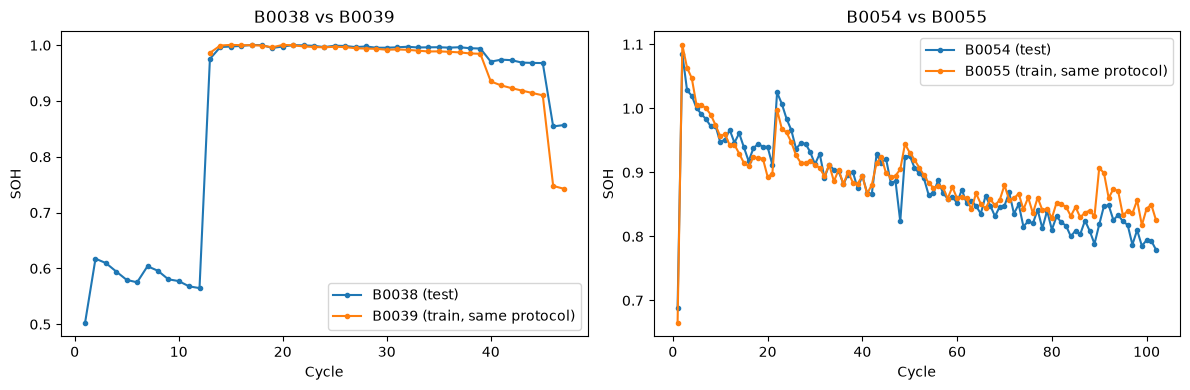

In [22]:
summary_check = pd.read_csv('cycle_summary_soh_rul_FINAL.csv')
pairs = [('B0038', 'B0039'), ('B0054', 'B0055')]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (suspect, twin) in zip(axes, pairs):
    s1 = summary_check[summary_check['battery_id'] == suspect]
    s2 = summary_check[summary_check['battery_id'] == twin]
    ax.plot(s1['cycle'], s1['soh'], label=f'{suspect} (test)', marker='.')
    ax.plot(s2['cycle'], s2['soh'], label=f'{twin} (train, same protocol)', marker='.')
    ax.set_xlabel('Cycle'); ax.set_ylabel('SOH')
    ax.legend(); ax.set_title(f'{suspect} vs {twin}')
plt.tight_layout()
plt.show()


## 16. Conclusions & Next Steps

- **Random Forest is currently the strongest model** for SOC estimation on this dataset, beating both neural approaches and the classical coulomb-counting baseline on MAE/RMSE.
- **All three ML approaches beat coulomb counting**, which is the correct headline result for this comparative study — coulomb counting's error compounds with depth of discharge (visible in its diagonal-fan error pattern), while the ML models see instantaneous sensor readings directly.
- **Known limitation:** training data uses only 4 discrete current levels (constant-current protocol), not the continuously variable load a real ESP32+WiFi device produces. Recommend augmenting with real hardware-collected variable-load data (already in progress).
- **Known limitation:** unit-to-unit aging variance (Section 15) creates an accuracy floor the model can't get past without knowing a battery's health state. Future work: cascade the SOH model's output as an auxiliary input to the SOC model.

### Edge deployment notes (ESP32-S3)
- MLP and LSTM convert directly to TFLite Micro (`tf.lite.TFLiteConverter`) -> `.tflite` -> C byte array.
- Random Forest has no native TFLite path — export as C code (e.g. `emlearn`, `m2cgen`) or keep as the offline comparative baseline only.
- Apply post-training int8 quantization on MLP/LSTM before conversion (~4x size reduction, small accuracy cost; ESP32-S3 has hardware acceleration for int8).
- Keep `WINDOW` small (12-20 steps) to limit on-device RAM for buffering the input sequence.

### Next notebook
Reuse this same pattern (protocol check, battery-level split, coulomb-counting-style baseline, 3-model comparison) for **SOH** and **RUL**, using `cycle_summary_soh_rul_FINAL.csv` instead of the per-timestep file.
